In [2]:
# CELL 1:  imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score,
    f1_score, roc_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')


In [4]:
# CELL 2: load data
df = pd.read_csv("C:/Users/Shalika/Desktop/FinalDataset.csv")

drop_cols = ['subject_id', 'hadm_id']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# split into features and label
X = df.drop(columns=['readmit_90'])
y = df['readmit_90']

print(f"Dataset shape: {X.shape}")
print(f"Class distribution:\n{y.value_counts(normalize=True).round(3)}")


Dataset shape: (94458, 79)
Class distribution:
readmit_90
0    0.912
1    0.088
Name: proportion, dtype: float64


In [6]:
# CELL 3: CFS selected features
# these 4 were selected by CFS in Weka
cfs_features = ['race_unknown','discharge_to_skilled_care', 'prior_admissions', 'min_sbp']
X_cfs = X[cfs_features]
print(f"CFS feature set shape: {X_cfs.shape}")
print(f"Features: {cfs_features}")


CFS feature set shape: (94458, 4)
Features: ['race_unknown', 'discharge_to_skilled_care', 'prior_admissions', 'min_sbp']


In [8]:
# CELL 4: model definitions
# imputer goes first in every pipeline so SMOTE doesn't crash on missing values
# SMOTE is inside the pipeline so it only sees training data and not test data 
models = {
    'Logistic Regression': ImbPipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('smote',   SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=1)),
        ('scaler',  StandardScaler()),
        ('clf',     LogisticRegression(
            C=1e8,
            max_iter=1000,
            random_state=1,
            class_weight='balanced'
        ))
    ]),

    'Naive Bayes': ImbPipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('smote',   SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=1)),
        ('clf',     GaussianNB())
    ]),

    'J48 (Decision Tree)': ImbPipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('smote',   SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=1)),
        ('clf',     DecisionTreeClassifier(
            criterion='gini',
            min_samples_leaf=2,
            random_state=1
        ))
    ]),

    # n_jobs=1 since -1 caused recall to drop to 0.01
    # parallel processing caused issues with SMOTE inside the pipeline
    'Random Forest': ImbPipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('smote',   SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=1)),
        ('clf',     RandomForestClassifier(
            n_estimators=100,
            random_state=1,
            n_jobs=1
        ))
    ])
}

# no SMOTE version of LR for the before/after comparison later
lr_no_smote = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler()),
    ('clf',     LogisticRegression(
        C=1e8,
        max_iter=1000,
        random_state=1,
        class_weight='balanced'
    ))
])

print("Models defined successfully")


Models defined successfully


In [10]:
#CELL 5:  evaluation functions
# two functions:
# run_single_model_default — uses 0.5 threshold (LR, NB, J48)
# run_single_model_prevalence — uses ~8.8% threshold (RF only)
# RF needed a different threshold because its predicted  probabilities clustered below 0.5 on the real test data so the default cutoff was flagging almost nobody as positive

def run_single_model_default(pipeline, X, y, model_name, feature_set):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
    aucs, recalls, precisions, f1s = [], [], [], []
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipeline.fit(X_train, y_train)
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        y_pred = pipeline.predict(X_test)

        aucs.append(roc_auc_score(y_test, y_prob))
        recalls.append(recall_score(y_test, y_pred))
        precisions.append(precision_score(y_test, y_pred, zero_division=0))
        f1s.append(f1_score(y_test, y_pred))

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        tprs.append(np.interp(mean_fpr, fpr, tpr))

    print(f"\n{model_name} ({feature_set})")
    print(f"  AUC:       {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
    print(f"  Recall:    {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
    print(f"  Precision: {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
    print(f"  F1:        {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

    return {
        'Model':     model_name,
        'Features':  feature_set,
        'AUC':       f"{np.mean(aucs):.3f} ± {np.std(aucs):.3f}",
        'Recall':    f"{np.mean(recalls):.3f} ± {np.std(recalls):.3f}",
        'Precision': f"{np.mean(precisions):.3f} ± {np.std(precisions):.3f}",
        'F1':        f"{np.mean(f1s):.3f} ± {np.std(f1s):.3f}",
        'mean_tprs': tprs,
        'mean_fpr':  mean_fpr,
        'mean_auc':  np.mean(aucs)
    }


def run_single_model_prevalence(pipeline, X, y, model_name, feature_set):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
    aucs, recalls, precisions, f1s = [], [], [], []
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipeline.fit(X_train, y_train)
        y_prob = pipeline.predict_proba(X_test)[:, 1]

        # use the actual readmission rate in the training fold as the cutoff
        threshold = y_train.mean()
        y_pred = (y_prob >= threshold).astype(int)

        aucs.append(roc_auc_score(y_test, y_prob))
        recalls.append(recall_score(y_test, y_pred))
        precisions.append(precision_score(y_test, y_pred, zero_division=0))
        f1s.append(f1_score(y_test, y_pred))

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        tprs.append(np.interp(mean_fpr, fpr, tpr))

    print(f"\n{model_name} ({feature_set}) [prevalence threshold]")
    print(f"  AUC:       {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
    print(f"  Recall:    {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
    print(f"  Precision: {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
    print(f"  F1:        {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

    return {
        'Model':     model_name,
        'Features':  feature_set,
        'AUC':       f"{np.mean(aucs):.3f} ± {np.std(aucs):.3f}",
        'Recall':    f"{np.mean(recalls):.3f} ± {np.std(recalls):.3f}",
        'Precision': f"{np.mean(precisions):.3f} ± {np.std(precisions):.3f}",
        'F1':        f"{np.mean(f1s):.3f} ± {np.std(f1s):.3f}",
        'mean_tprs': tprs,
        'mean_fpr':  mean_fpr,
        'mean_auc':  np.mean(aucs)
    }

print("Functions defined successfully")


Functions defined successfully


In [12]:
#CELL 6: run all models on full 79 features
# this takes the longest - Random Forest especially
all_results = []

print("=" * 60)
print("RUNNING MODELS — FULL FEATURE SET (79 features)")
print("=" * 60)

for name, model in models.items():
    if name != 'Random Forest':
        result = run_single_model_default(model, X, y, name, 'All 79 features')
        all_results.append(result)

# RF uses the prevalence threshold
rf_full = run_single_model_prevalence(
    models['Random Forest'], X, y, 'Random Forest', 'All 79 features'
)
all_results.append(rf_full)

print("\nFull feature set done!")


RUNNING MODELS — FULL FEATURE SET (79 features)

Logistic Regression (All 79 features)
  AUC:       0.706 ± 0.007
  Recall:    0.625 ± 0.015
  Precision: 0.154 ± 0.003
  F1:        0.247 ± 0.005

Naive Bayes (All 79 features)
  AUC:       0.627 ± 0.007
  Recall:    0.400 ± 0.157
  Precision: 0.150 ± 0.020
  F1:        0.209 ± 0.008

J48 (Decision Tree) (All 79 features)
  AUC:       0.540 ± 0.005
  Recall:    0.143 ± 0.012
  Precision: 0.153 ± 0.012
  F1:        0.148 ± 0.012

Random Forest (All 79 features) [prevalence threshold]
  AUC:       0.694 ± 0.007
  Recall:    0.784 ± 0.012
  Precision: 0.124 ± 0.002
  F1:        0.215 ± 0.003

Full feature set done!


In [14]:
#CELL 7:  run all models on CFS 4 features
# much faster since only 3 features
print("=" * 60)
print("RUNNING MODELS — CFS SUBSET (3 features)")
print("=" * 60)

for name, model in models.items():
    if name != 'Random Forest':
        result = run_single_model_default(model, X_cfs, y, name, 'CFS 4 features')
        all_results.append(result)

rf_cfs = run_single_model_prevalence(
    models['Random Forest'], X_cfs, y, 'Random Forest', 'CFS 4 features'
)
all_results.append(rf_cfs)

print("\nCFS subset done!")


RUNNING MODELS — CFS SUBSET (4 features)

Logistic Regression (CFS 4 features)
  AUC:       0.679 ± 0.007
  Recall:    0.505 ± 0.017
  Precision: 0.166 ± 0.004
  F1:        0.250 ± 0.007

Naive Bayes (CFS 4 features)
  AUC:       0.667 ± 0.010
  Recall:    0.847 ± 0.030
  Precision: 0.107 ± 0.003
  F1:        0.190 ± 0.003

J48 (Decision Tree) (CFS 4 features)
  AUC:       0.564 ± 0.010
  Recall:    0.331 ± 0.010
  Precision: 0.128 ± 0.004
  F1:        0.185 ± 0.006

Random Forest (CFS 4 features) [prevalence threshold]
  AUC:       0.571 ± 0.010
  Recall:    0.861 ± 0.016
  Precision: 0.093 ± 0.001
  F1:        0.167 ± 0.003

CFS subset done!


In [16]:
# CELL 8:SMOTE vs no SMOTE comparison
# running LR here to show what happens without balancing → might be interesting to compare against Weka 
print("=" * 60)
print("SMOTE vs NO SMOTE — Logistic Regression")
print("=" * 60)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
aucs_no_smote, recalls_no_smote = [], []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    lr_no_smote.fit(X_train, y_train)
    y_pred = lr_no_smote.predict(X_test)
    y_prob = lr_no_smote.predict_proba(X_test)[:, 1]
    aucs_no_smote.append(roc_auc_score(y_test, y_prob))
    recalls_no_smote.append(recall_score(y_test, y_pred))

print(f"\nWithout SMOTE:")
print(f"  AUC:    {np.mean(aucs_no_smote):.3f} ± {np.std(aucs_no_smote):.3f}")
print(f"  Recall: {np.mean(recalls_no_smote):.3f} ± {np.std(recalls_no_smote):.3f}")


SMOTE vs NO SMOTE — Logistic Regression

Without SMOTE:
  AUC:    0.708 ± 0.007
  Recall: 0.627 ± 0.017


In [18]:
smote_result = next(r for r in all_results
                    if r['Model'] == 'Logistic Regression'
                    and r['Features'] == 'All 79 features')
print(f"\nWith SMOTE:")
print(f"  AUC:    {smote_result['AUC']}")
print(f"  Recall: {smote_result['Recall']}")



With SMOTE:
  AUC:    0.706 ± 0.007
  Recall: 0.625 ± 0.015


Generating ROC curves...
All 79 features -> 4 runs
CFS 4 features -> 4 runs


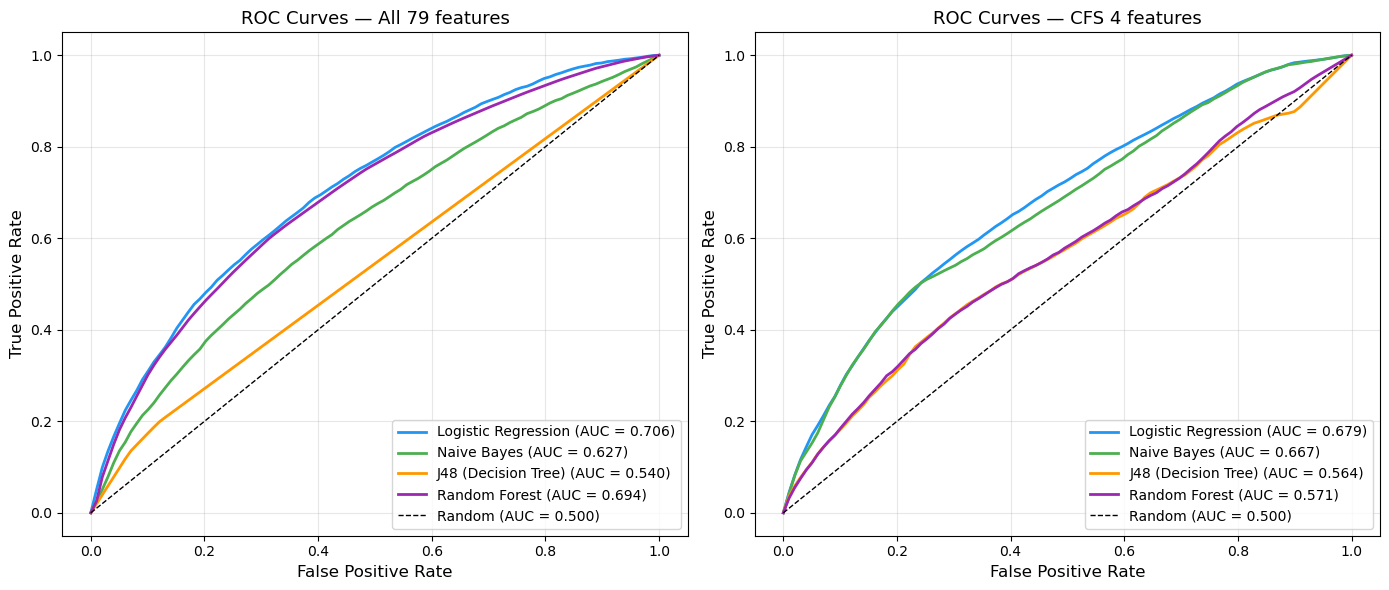

Saved to roc_curves.png


In [20]:
print("Generating ROC curves...")

import matplotlib.pyplot as plt
import numpy as np

feature_sets = sorted(set(r['Features'] for r in all_results))

fig, axes = plt.subplots(1, len(feature_sets), figsize=(14, 6))

if len(feature_sets) == 1:
    axes = [axes]

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for plot_idx, feature_set in enumerate(feature_sets):
    ax = axes[plot_idx]

    subset = [r for r in all_results if r['Features'] == feature_set]
    print(f"{feature_set} -> {len(subset)} runs")

    if len(subset) == 0:
        ax.set_title(f"{feature_set} (No Data)", fontsize=13)
        ax.axis('off')
        continue

    seen_labels = set()

    for i, result in enumerate(subset):

        mean_tpr = np.mean(result['mean_tprs'], axis=0)
        mean_tpr[0] = 0.0

        label = f"{result['Model']} (AUC = {result['mean_auc']:.3f})"

        # Prevent duplicate legend entries
        if label in seen_labels:
            label = None
        else:
            seen_labels.add(label)

        ax.plot(
            result['mean_fpr'],
            mean_tpr,
            color=colors[i % len(colors)],
            label=label,
            linewidth=2
        )

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')

    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'ROC Curves — {feature_set}', fontsize=13)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved to roc_curves.png")

In [57]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
import lime
import lime.lime_tabular

# 1. CLEAN COLUMNS: Drop constant columns
X_lime = X.loc[:, X.nunique() > 1]

# 2. FILL NaNs: LIME needs a dataset with no missing values to calculate distances
# We'll use the same strategy as your pipeline (mean)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_lime)

# 3. ADD NOISE: Final safety check for the previous Domain Error
X_final = X_imputed + np.random.normal(0, 1e-10, X_imputed.shape)

# 4. RE-FIT THE MODEL
# Your model stays the same, but we fit it on the filtered features
explainer_model = models['Random Forest']
explainer_model.fit(X_lime, y)

# 5. INITIALIZE LIME
# Note: We pass X_final (no NaNs, no constants)
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_final,
    feature_names=X_lime.columns.tolist(),
    class_names=['Stayed', 'Readmitted'],
    mode='classification',
    discretize_continuous=False # Keeps the math stable
)

# 6. EXPLAIN A SPECIFIC CASE
# Important: The 'instance' must also be imputed/clean
sample_idx = np.where(y == 1)[0][0]
instance = X_imputed[sample_idx] # Grab from the imputed array

exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=explainer_model.predict_proba,
    num_features=10
)

# 7. SHOW RESULTS
exp.show_in_notebook(show_table=True)